# Plot sea ice coverage over time (FLOR, CM2.1)

Figure 3, S4

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
plt.style.use('../func/PPT.mplstyle')

In [2]:
from misc_func import find_files
from solar_func import rename_latlon

# plot world maps over time

In [3]:
# Add a y-axis label

def set_yax_label(ax,text,x,y,fontsize=20):
    ax.text(
        x, y, text, 
        va="center", ha="center", 
        rotation="vertical", 
        transform=ax.transAxes,
        fontsize=fontsize,
    )

# sea ice

In [4]:
# load data
FLOR_m6_ice_months = xr.open_dataarray('./processed_data/count_ice_months_MI_FLOR_m6p0sol_CTL1860.nc')
CM21_m6_ice_months = xr.open_dataarray('./processed_data/count_ice_months_MI_CM2.1p1_CTL1860_m6pctSolar.nc')

FLOR_m6_ice_months = rename_latlon(FLOR_m6_ice_months)
CM21_m6_ice_months = rename_latlon(CM21_m6_ice_months)

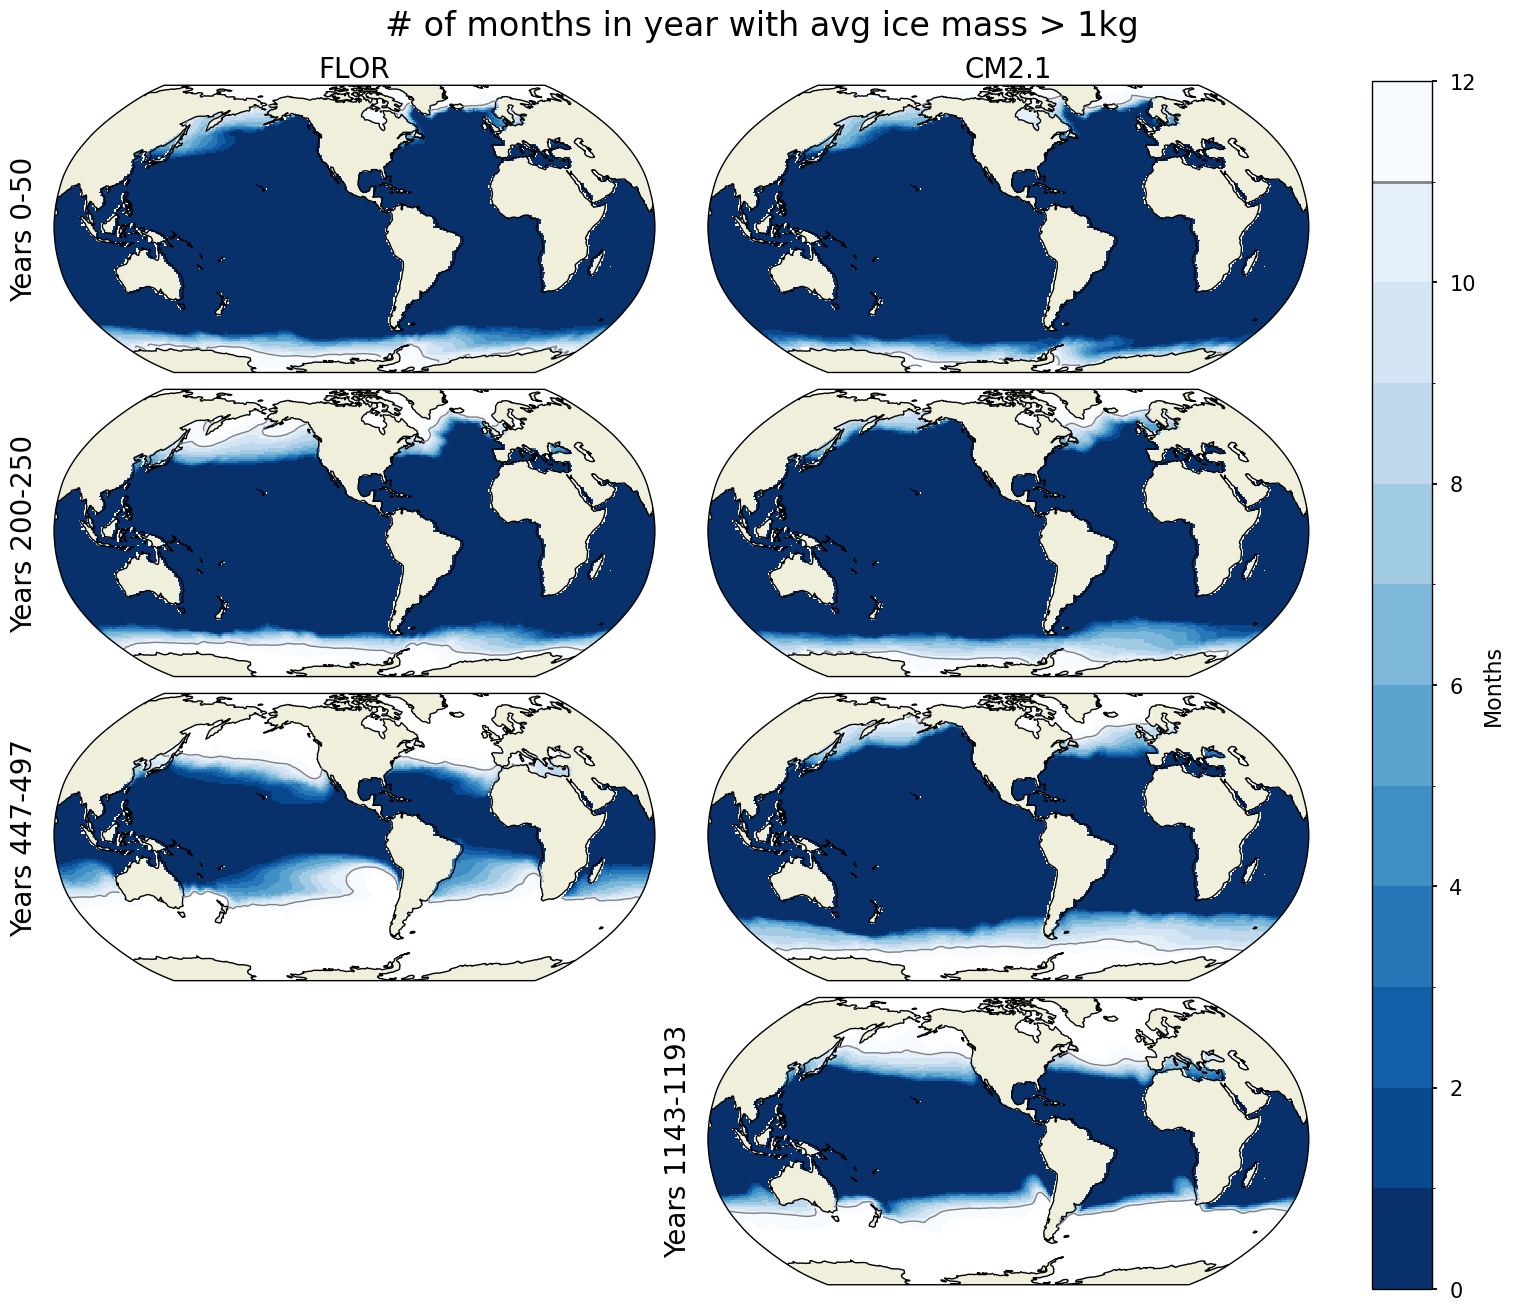

In [5]:
# plot average months of year where ice mass>1

import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean as cmo

yrs = np.array([[0,50],[200,250],[497-50,497],[1193-50,1193]])

fig, ax = plt.subplots(4,2,constrained_layout=True,
                       figsize=(15,13),
                      subplot_kw={'projection': ccrs.Robinson(central_longitude=-100)})

for ii in range(4):

    if ii < 3:
        si_flor = FLOR_m6_ice_months.isel(year=slice(yrs[ii,0],yrs[ii,1])).mean('year')
        ctr = si_flor.plot(ax=ax[ii,0],
                           transform=ccrs.PlateCarree(),
                           cmap='Blues_r',levels=13,
                           add_colorbar=False,rasterized=True)
    ax[ii,0].contour(si_flor['lon'], si_flor['lat'], si_flor,
                     levels=[11], colors='gray', linewidths=1,
                     transform=ccrs.PlateCarree())

    si_cm21 = CM21_m6_ice_months.isel(year=slice(yrs[ii,0],yrs[ii,1])).mean('year')
    ctr = si_cm21.plot(ax=ax[ii,1],
                       transform=ccrs.PlateCarree(),
                       cmap='Blues_r',levels=13,
                       add_colorbar=False,rasterized=True)
    
    ax[ii,1].contour(si_cm21['lon'], si_cm21['lat'], si_cm21,
                     levels=[11], colors='gray', linewidths=1,
                     transform=ccrs.PlateCarree())
    
    ax[ii,0].set_title('')
    ax[ii,1].set_title('')
    
    ax[ii,0].add_feature(cfeature.LAND)
    ax[ii,0].coastlines()
    ax[ii,1].add_feature(cfeature.LAND)
    ax[ii,1].coastlines()

cb = fig.colorbar(ctr, ax=ax[:])
cb.ax.set_ylabel('Months', fontsize=16)
cb.ax.tick_params(labelsize=15)
# Add black contour line to colorbar
cb.ax.axhline(11, color='gray', linewidth=2)

ax[0,0].set_title('FLOR')                                                                           
ax[0,1].set_title('CM2.1')
fig.suptitle('# of months in year with avg ice mass > 1kg')

# use function 
set_yax_label(ax[0,0],f'Years {yrs[0,0]}-{yrs[0,1]}',-0.05,0.5, fontsize=20)
set_yax_label(ax[1,0],f'Years {yrs[1,0]}-{yrs[1,1]}',-0.05,0.5, fontsize=20)
set_yax_label(ax[2,0],f'Years {yrs[2,0]}-{yrs[2,1]}',-0.05,0.5, fontsize=20)
set_yax_label(ax[3,1],f'Years {yrs[3,0]}-{yrs[3,1]}',-0.05,0.5, fontsize=20)

# Make lower-left subplot empty
ax[3,0].set_visible(False)

plt.savefig('FigureS3.pdf', bbox_inches='tight', dpi=200)

# SST

In [6]:
# import SST data
FLOR_m6_SST = xr.open_dataarray('./MODEL_OUT/SST_FLOR_m6p0sol_CTL1860_tigercpu_intelmpi_18_576PE_0101-0597_output.nc')
CM21_m6_SST = xr.open_dataarray('./MODEL_OUT/SST_CM2.1p1_CTL1860_m6pctSolar_tigercpu_intelmpi_18_80PE_0101-1293_output.nc')

FLOR_m6_SST = rename_latlon(FLOR_m6_SST)
CM21_m6_SST = rename_latlon(CM21_m6_SST)

In [7]:
CM21_m6_SST

<xarray.DataArray 'SST' (time: 14316, lat: 200, lon: 360)> Size: 4GB
[1030752000 values with dtype=float32]
Coordinates:
  * time     (time) object 115kB 0101-01-16 12:00:00 ... 1293-12-16 12:00:00
  * lon      (lon) float64 3kB -279.5 -278.6 -277.6 -276.6 ... 77.6 78.56 79.52
  * lat      (lat) float64 2kB -81.5 -80.5 -79.5 -78.5 ... 78.35 78.62 78.78
Attributes:
    long_name:      sea surface temperature
    units:          deg-C
    cell_methods:   time: mean
    time_avg_info:  average_T1,average_T2,average_DT

In [8]:
# # get annual means
# FLOR_m6_SST = FLOR_m6_SST.groupby('time.year').mean('time')
# CM21_m6_SST = CM21_m6_SST.groupby('time.year').mean('time')

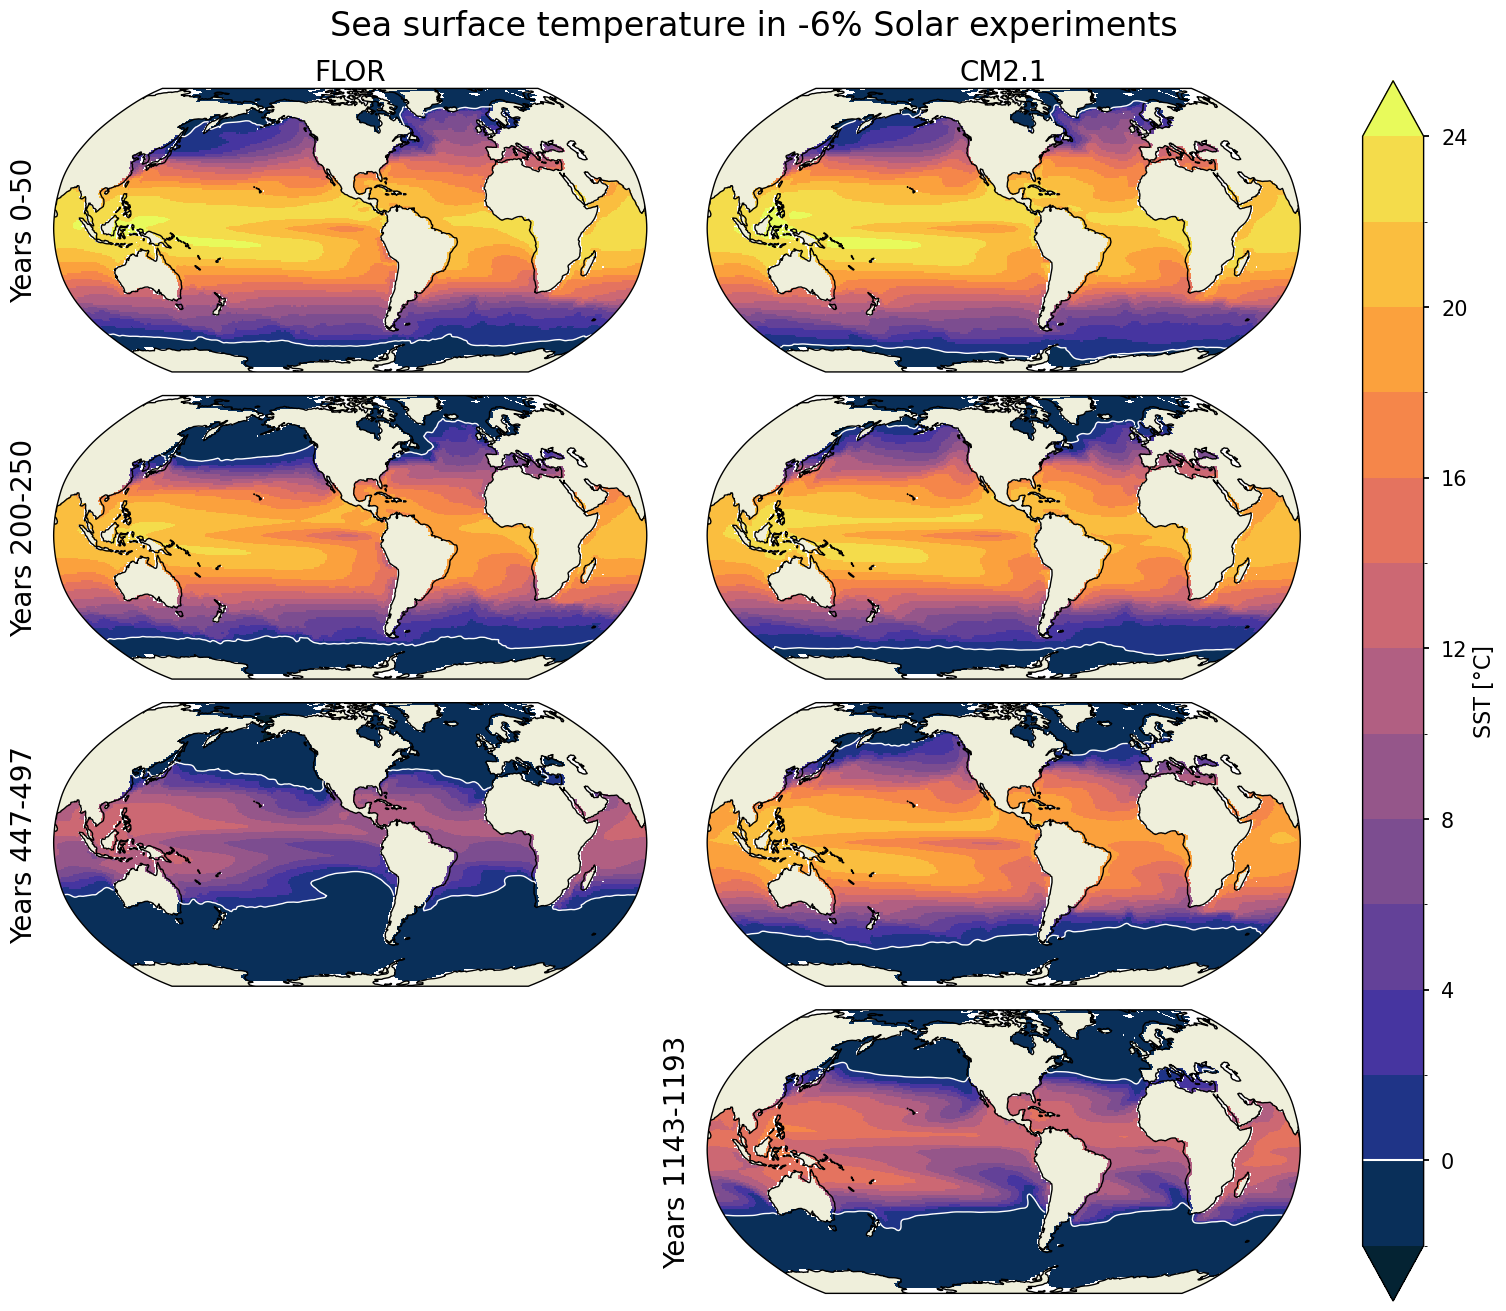

In [9]:
# plot average SST
# takes a few minutes

import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean as cmo

yrs = np.array([[0,50],[200,250],[497-50,497],[1193-50,1193]])

fig, ax = plt.subplots(4,2,constrained_layout=True,
                       figsize=(15,13),
                      subplot_kw={'projection': ccrs.Robinson(central_longitude=-100)})

levels = np.arange(-2,26,2)

for ii in range(4):

    if ii < 3:
        # FLOR
        sst_flor = FLOR_m6_SST.isel(time=slice(yrs[ii,0]*12, yrs[ii,1]*12)).mean('time')
        ctr = sst_flor.plot(ax=ax[ii,0],
                            transform=ccrs.PlateCarree(),
                            cmap='cmo.thermal',
                            levels=levels,
                            add_colorbar=False,
                            rasterized=True,
                            extend='both')
        ax[ii,0].contour(sst_flor['lon'], sst_flor['lat'], sst_flor,
                         levels=[0], colors='white', linewidths=1,
                         transform=ccrs.PlateCarree())
        # save file to processed data
        sst_flor.to_netcdf(f'./processed_data/SST_FLOR_m6pctSolar_yr_{yrs[ii,0]}_{yrs[ii,1]}.nc')
        

    # CM2.1
    sst_cm21 = CM21_m6_SST.isel(time=slice(yrs[ii,0]*12, yrs[ii,1]*12)).mean('time')
    ctr = sst_cm21.plot(ax=ax[ii,1],
                        transform=ccrs.PlateCarree(),
                        cmap='cmo.thermal',
                        levels=levels,
                        add_colorbar=False,
                        rasterized=True,
                        extend='both')
    ax[ii,1].contour(sst_cm21['lon'], sst_cm21['lat'], sst_cm21,
                     levels=[0], colors='white', linewidths=1,
                     transform=ccrs.PlateCarree())
    # save file to processed data
    sst_cm21.to_netcdf(f'./processed_data/SST_CM2.1p1_m6pctSolar_yr_{yrs[ii,0]}_{yrs[ii,1]}.nc')

    # map features
    ax[ii,0].set_title('')
    ax[ii,1].set_title('')
    ax[ii,0].add_feature(cfeature.LAND)
    ax[ii,0].coastlines()
    ax[ii,1].add_feature(cfeature.LAND)
    ax[ii,1].coastlines()

cb = fig.colorbar(ctr, ax=ax[:])
cb.ax.set_ylabel('SST [°C]', fontsize=16)
cb.ax.tick_params(labelsize=15)
# Add white zero-contour line to colorbar
cb.ax.axhline(0, color='white', linewidth=1.5)

ax[0,0].set_title('FLOR')                                                                           
ax[0,1].set_title('CM2.1')
fig.suptitle('Sea surface temperature in -6% Solar experiments')

# use function 
set_yax_label(ax[0,0],f'Years {yrs[0,0]}-{yrs[0,1]}',-0.05,0.5, fontsize=20)
set_yax_label(ax[1,0],f'Years {yrs[1,0]}-{yrs[1,1]}',-0.05,0.5, fontsize=20)
set_yax_label(ax[2,0],f'Years {yrs[2,0]}-{yrs[2,1]}',-0.05,0.5, fontsize=20)
set_yax_label(ax[3,1],f'Years {yrs[3,0]}-{yrs[3,1]}',-0.05,0.5, fontsize=20)

# Make lower-left subplot empty
ax[3,0].set_visible(False)

plt.savefig('FigureS4.pdf', bbox_inches='tight', dpi=200)